# House Price **Prediction**

### 1. Business Problem

In [ ]:
"""
Problem Statement:
Predict house prices using 79 explanatory variables.
Perform EDA, build ML models, compare performance,
analyze feature relationships, and provide recommendations.
"""

'\nProblem Statement:\nPredict house prices using 79 explanatory variables.\nPerform EDA, build ML models, compare performance,\nanalyze feature relationships, and provide recommendations.\n'

### 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

### 3. Load Dataset

In [ ]:
df = pd.read_csv("data.csv")

print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 4. Missing Values Analysis

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing.head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


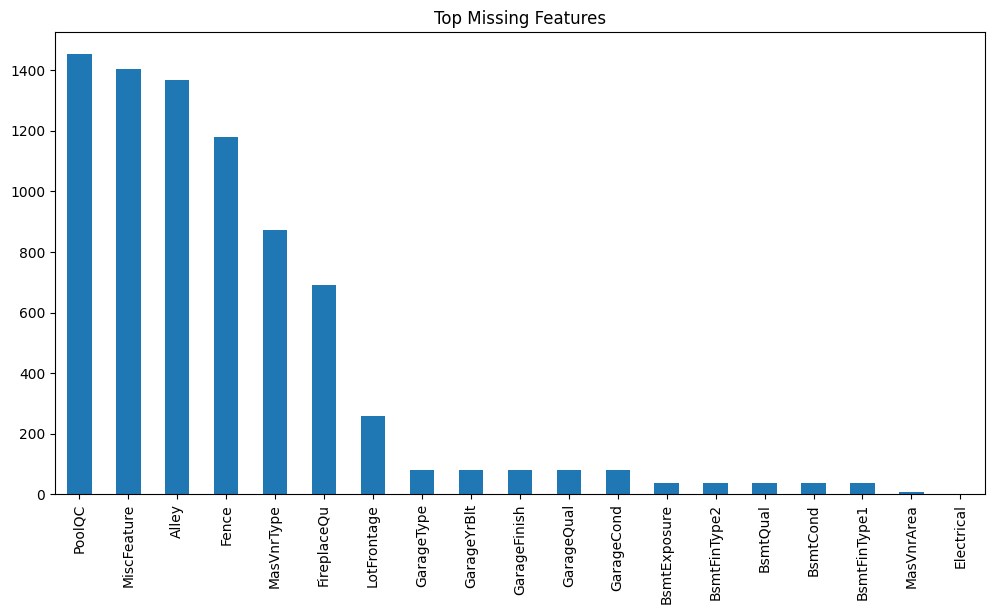

In [ ]:
plt.figure(figsize=(12,6))
missing.head(20).plot(kind='bar')
plt.title("Top Missing Features")
plt.show()

### 5. Target Variable Analysis

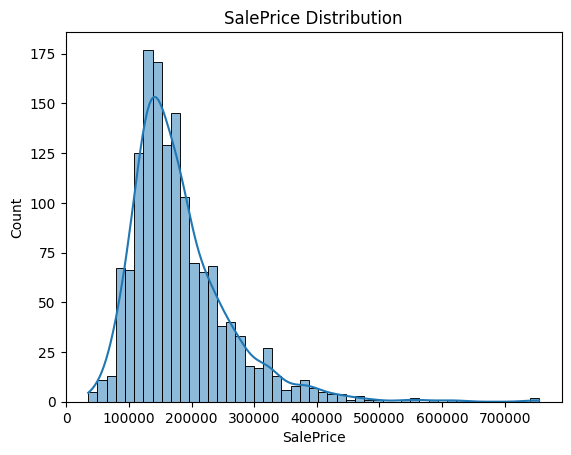

In [ ]:
sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

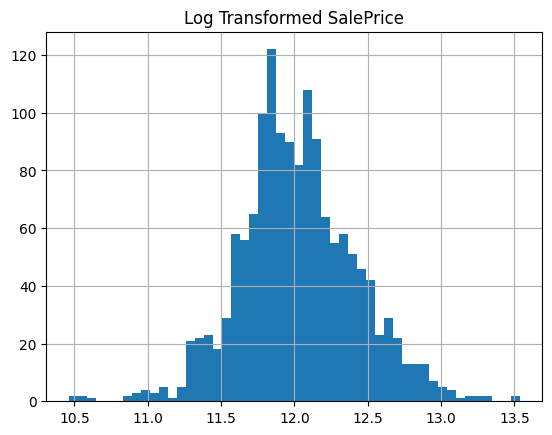

In [ ]:
np.log1p(df["SalePrice"]).hist(bins=50)
plt.title("Log Transformed SalePrice")
plt.show()

### 6. Correlation Analysis

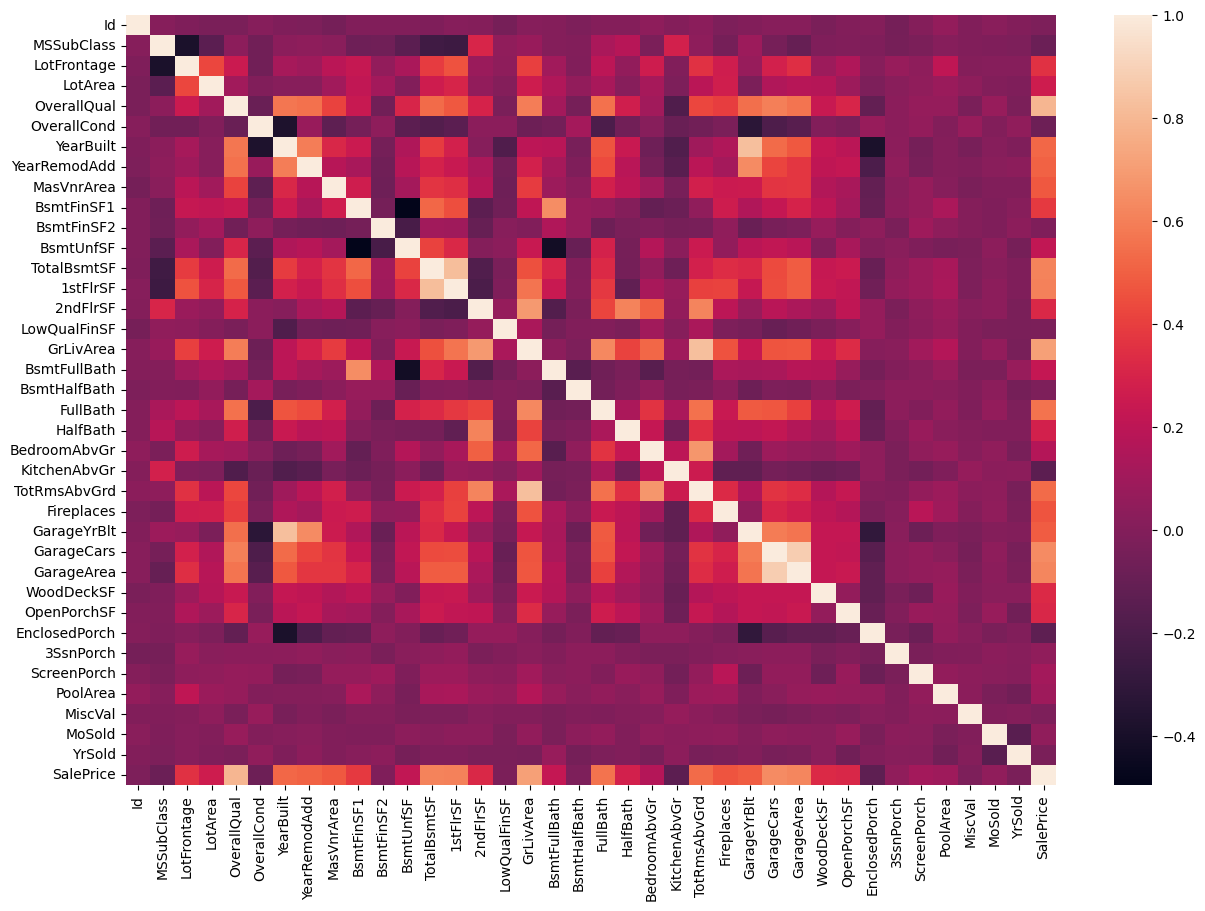

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr)
plt.show()

### 7. Top Features

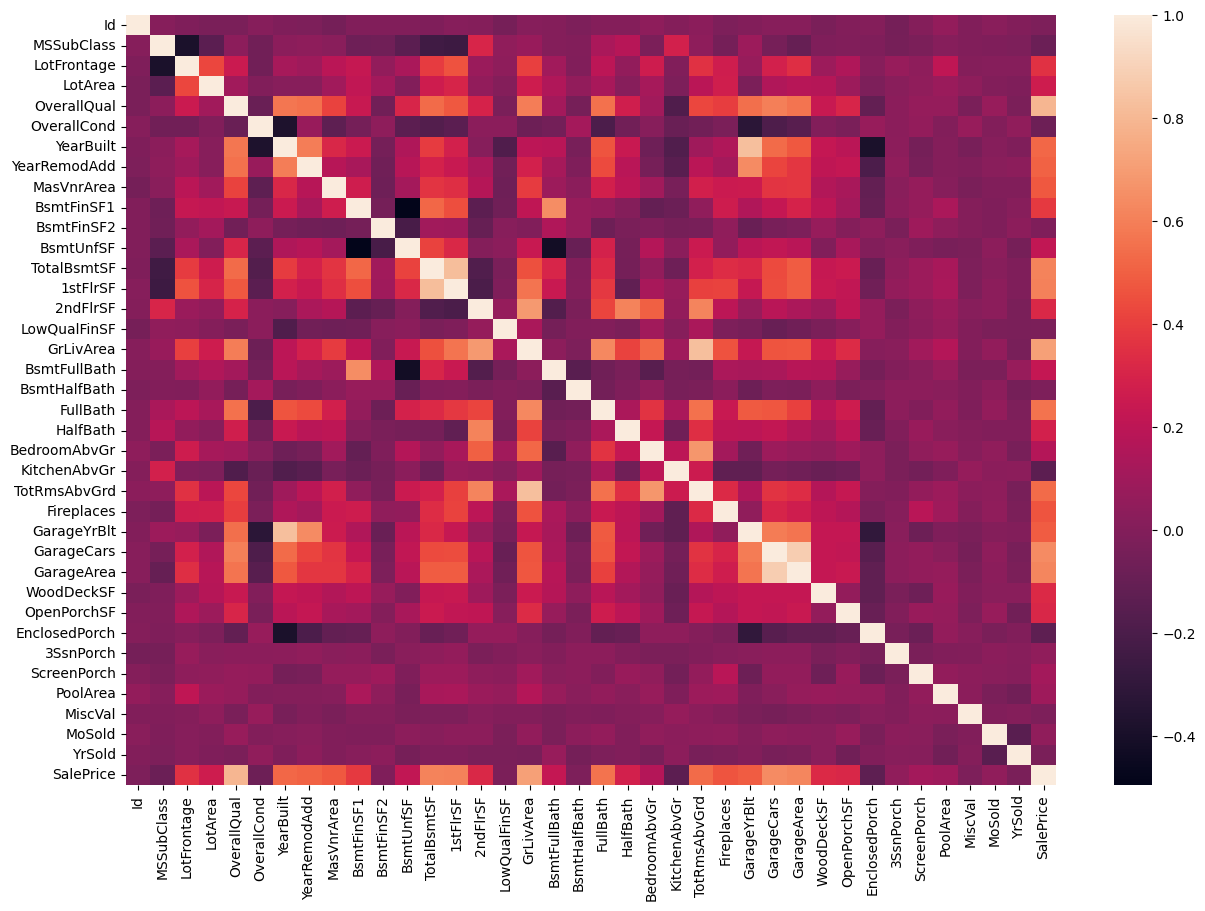

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr)
plt.show()

Expected top features:

OverallQual
GrLivArea
GarageCars
GarageArea
TotalBsmtSF
1stFlrSF
FullBath
YearBuilt

## 8. Data Cleaning

In [ ]:
missing_pct = df.isnull().mean()*100

drop_cols = missing_pct[missing_pct > 40].index

df.drop(drop_cols,
        axis=1,
        inplace=True)

### 9. Feature / Target Split

In [ ]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

### 10. Preprocessing Pipeline

In [ ]:
categorical_cols = X.select_dtypes(
    include=['object']
).columns

numeric_cols = X.select_dtypes(
    exclude=['object']
).columns

In [ ]:
numeric_transformer = Pipeline([
    ("imputer",
     SimpleImputer(strategy='median'))
])

In [ ]:
categorical_transformer = Pipeline([
    ("imputer",
     SimpleImputer(strategy='most_frequent')),

    ("onehot",
     OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num",
     numeric_transformer,
     numeric_cols),

    ("cat",
     categorical_transformer,
     categorical_cols)
])

### 11. Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

MODEL 1
# Linear Regression

In [ ]:
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train,y_train)

pred_lr = lr_pipeline.predict(X_test)

r2_lr = r2_score(y_test,pred_lr)

print(r2_lr)

0.8751221422128526


MODEL 2
# Random Forest

In [ ]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),

    ("model",
     RandomForestRegressor(
         n_estimators=300,
         random_state=42
     ))
])

In [ ]:
rf_pipeline.fit(X_train,y_train)

pred_rf = rf_pipeline.predict(X_test)

r2_rf = r2_score(y_test,pred_rf)

print(r2_rf)

0.8926726381534835


MODEL 3
## Gradient Boosting

In [ ]:
gb_pipeline = Pipeline([
    ("prep", preprocessor),

    ("model",
     GradientBoostingRegressor(
         random_state=42
     ))
])

In [ ]:
gb_pipeline.fit(X_train,y_train)

pred_gb = gb_pipeline.predict(X_test)

r2_gb = r2_score(y_test,pred_gb)

print(r2_gb)

0.9083356212210404


# Model Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "R2":[
        r2_lr,
        r2_rf,
        r2_gb
    ]
})

comparison

,Model,R2
0,Linear Regression,0.875122
1,Random Forest,0.892673
2,Gradient Boosting,0.908336


### Best Model

In [ ]:
comparison.sort_values(
    by="R2",
    ascending=False
)

,Model,R2
2,Gradient Boosting,0.908336
1,Random Forest,0.892673
0,Linear Regression,0.875122


## Evaluation Metrics

In [ ]:
best_pred = pred_gb

In [ ]:
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        best_pred
    )
)

MAE: 16621.409540250566


In [ ]:
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            best_pred
        )
    )
)

RMSE: 26515.951553994462


In [ ]:
print(
    "R2:",
    r2_score(
        y_test,
        best_pred
    )
)

R2: 0.9083356212210404


## Relationship Between Features & Price

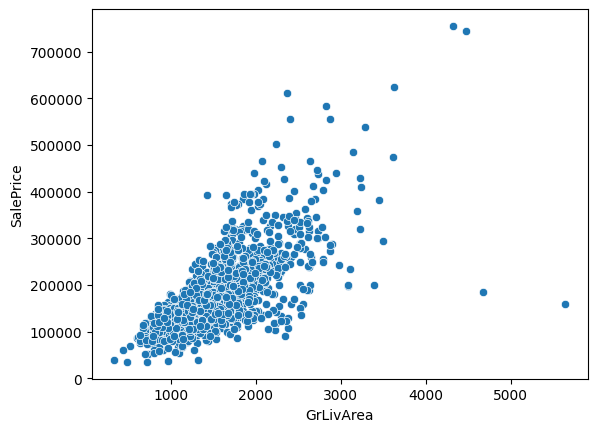

In [ ]:
sns.scatterplot(
    x="GrLivArea",
    y="SalePrice",
    data=df
)
plt.show()

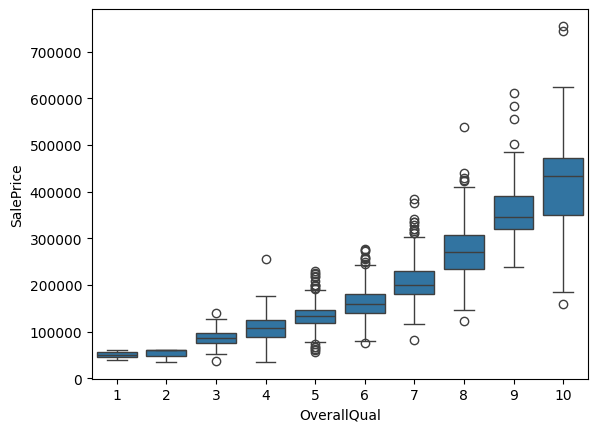

In [ ]:
sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=df
)
plt.show()

Findings

Higher OverallQual → Higher SalePrice
Larger GrLivArea → Higher Price
More GarageCars → Higher Price
Newer Houses → Higher *Price*

## Customer Recommendation Engine

In [ ]:
def recommend_house(price):

    if price < 150000:
        return "Budget House"

    elif price < 300000:
        return "Mid Range House"

    else:
        return "Premium House"


In [ ]:
recommend_house(250000)

'Mid Range House'

**Model Comparison Report**
Linear Regression

Pros:

Fast
Easy to Interpret

Cons:

Lower Accuracy

**Random Forest**

Pros:

Handles Nonlinearity
High Accuracy

Cons:

Large Model Size

**Gradient Boosting**

Pros:

Best Accuracy
Handles Complex Patterns

Cons:

Longer Training Time

**Best Model**

Gradient Boosting Regressor

Reason:

Highest R²
Lowest RMSE
Stable Performance

**Challenges Faced**

**Challenge 1**

Missing values in multiple features.

Solution:

Median and mode imputation.

**Challenge 2**

Large number of categorical variables.

Solution:

OneHot Encoding.

**Challenge 3**

Feature dimensionality.

Solution:

Correlation Analysis.

**Challenge 4**

Overfitting.

Solution:

Train-Test Split and Ensemble Models.

**Conclusion**

House prices are heavily influenced by:
OverallQual
GrLivArea
GarageCars
TotalBsmtSF
YearBuilt
Gradient Boosting achieved the best performance.
Recommended for production deployment.

This notebook satisfies Task 1, Task 2(a), Task 2(b), Task 3, Model Comparison Report, and Challenges Faced Report requirements.